In [2]:
import numpy as np
import agama
import matplotlib.pyplot as plt
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm
from reverse_orbit import reverse_orbit
agama.setUnits(length=1, velocity=1, mass=1)  # kpc, km/s, Solar mass

import sys
sys.path.append('/suphys/aani0116/Work/minicluster_tidal/stellar')
from N_calculator import N_encounter 
from N_calculator import stellar_rho_total
from scipy.stats import uniform_direction




In [3]:
pot_mw = agama.Potential(
    dict(type='Dehnen', mass=1.0e10, scaleRadius=1.0, gamma=1),       # Bulge
    dict(type='MiyamotoNagai', mass=5.0e10, scaleRadius=3.0, scaleHeight=0.3),  # Disk
    dict(type='NFW', mass=2e12, scaleRadius=22.0))                     # Dark matter halo

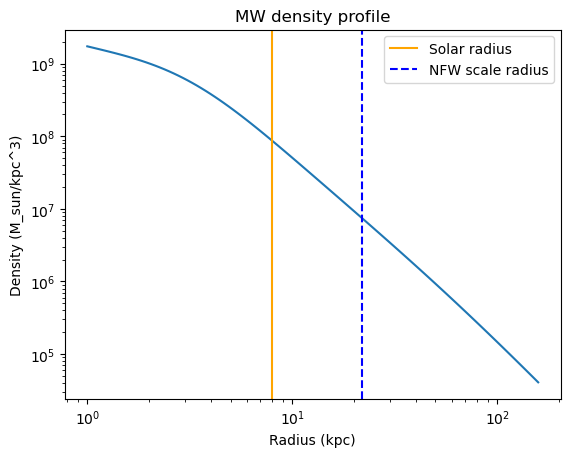

In [4]:
# Non-essential: MW density profile
r_array = np.logspace(0, 2.2, 100)
pts = np.column_stack((r_array, np.zeros_like(r_array), np.zeros_like(r_array)))
rho_mw = pot_mw.density(pts)

plt.figure()
plt.loglog(r_array, rho_mw)
plt.axvline(8.0, color='orange', label='Solar radius')
plt.axvline(22.0, color='b', linestyle='--', label='NFW scale radius')
plt.xlabel('Radius (kpc)')
plt.ylabel('Density (M_sun/kpc^3)')
plt.title('MW density profile')
plt.legend()
plt.show()

In [5]:
mc_mass0 = 1e-3# Solar masses
mc_rvir  = 1e-4  # virial radius [kpc]
mc_rs    = 1e-5   # scale radius [kpc]
Nbody    = 500

In [6]:
pot_mc = agama.Potential(
    type='spheroid', gamma=1, beta=3,
    scaleradius=mc_rs, outercutoffradius=mc_rvir, mass=mc_mass0)

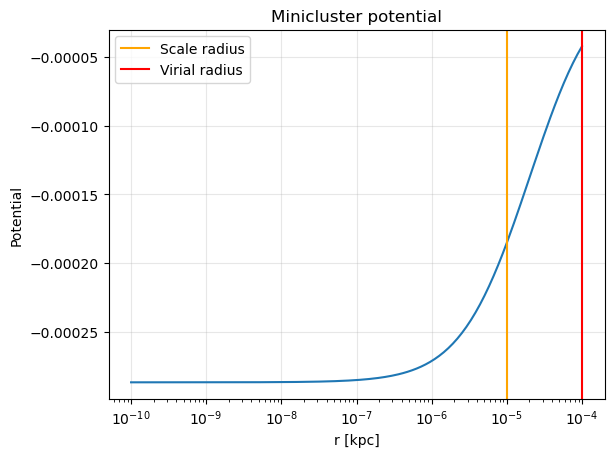

In [6]:
r = np.logspace(-10, -4, 200)  # adjust range to your units
pts = np.column_stack((r, np.zeros_like(r), np.zeros_like(r)))

plt.figure()
plt.semilogx(r, pot_mc.potential(pts))
plt.xlabel('r [kpc]')
plt.ylabel('Potential')
plt.title('Minicluster potential')
plt.axvline(mc_rs, color='orange', label='Scale radius')
plt.axvline(mc_rvir, color='r', label='Virial radius')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


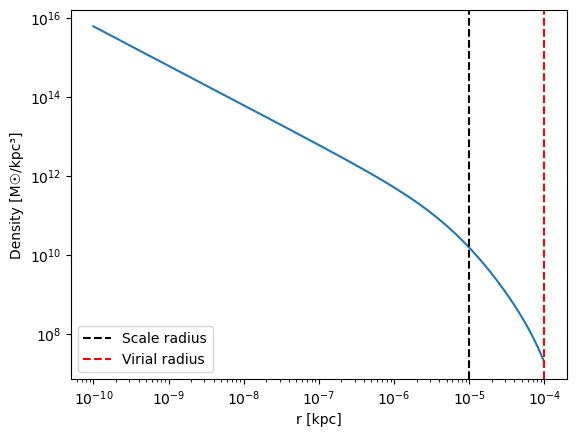

In [7]:
plt.figure()
plt.loglog(r, pot_mc.density(pts))
plt.xlabel('r [kpc]')
plt.ylabel('Density [M☉/kpc³]')
plt.axvline(mc_rs,   color='k', linestyle='--', label='Scale radius')
plt.axvline(mc_rvir, color='r', linestyle='--', label='Virial radius')
plt.legend()
plt.show()


In [8]:
#distribution function for mc is initialised, limit 1e-6kpc, PROBLEMATIC.
df_mc   = agama.DistributionFunction(type='quasispherical', potential=pot_mc)
mc_mass0 = pot_mc.totalMass()  # exact mass after cutoff

In [9]:
#particles are sampled from the distribution function, with positions and velocities.
mcp_xv, mcp_mass = agama.GalaxyModel(pot_mc, df_mc).sample(Nbody)


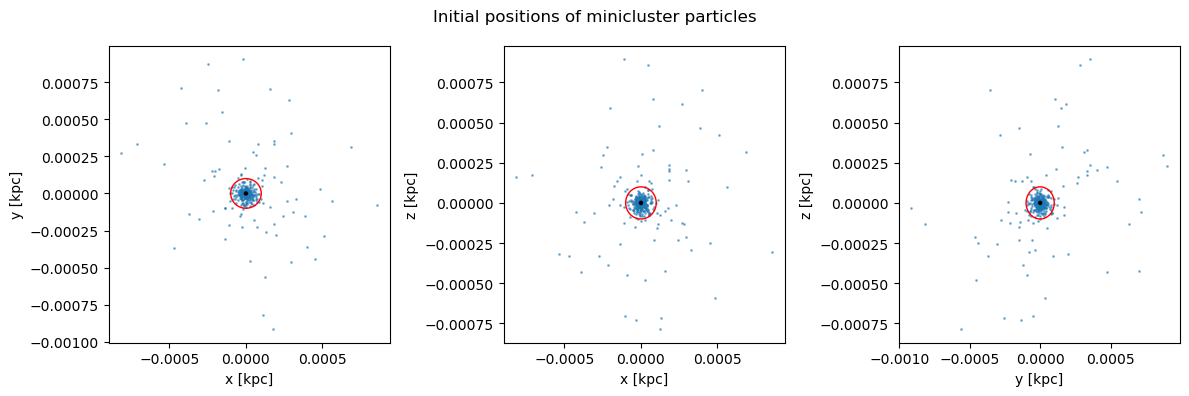

In [10]:
fig,ax=plt.subplots(1,3, figsize=(12,4))
fig.suptitle('Initial positions of minicluster particles')

ax[0].scatter(mcp_xv[:,0], mcp_xv[:,1], s=1, alpha=0.5)
ax[0].set_xlabel('x [kpc]')
ax[0].set_ylabel('y [kpc]')
ax[0].add_patch(plt.Circle((0, 0), mc_rvir, color='r', fill=False, label='Virial radius'))
ax[0].add_patch(plt.Circle((0, 0), mc_rs,   color='k', fill=True,  label='Scale radius'))


ax[1].scatter(mcp_xv[:,0], mcp_xv[:,2],s=1, alpha=0.5) 
ax[1].set_xlabel('x [kpc]')
ax[1].set_ylabel('z [kpc]')
ax[1].add_patch(plt.Circle((0, 0), mc_rvir, color='r', fill=False, label='Virial radius'))
ax[1].add_patch(plt.Circle((0, 0), mc_rs,   color='k', fill=True,  label='Scale radius'))


ax[2].scatter(mcp_xv[:,1], mcp_xv[:,2],s=1, alpha=0.5)
ax[2].set_xlabel('y [kpc]')
ax[2].set_ylabel('z [kpc]')
ax[2].add_patch(plt.Circle((0, 0), mc_rvir, color='r', fill=False, label='Virial radius'))
ax[2].add_patch(plt.Circle((0, 0), mc_rs,   color='k', fill=True,  label='Scale radius'))




plt.tight_layout()
plt.show()

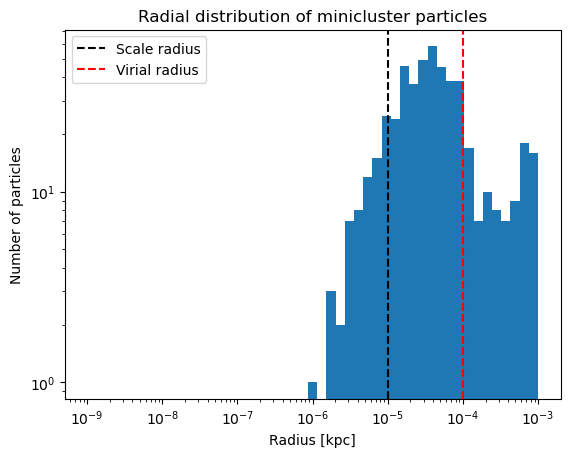

Number of particles within scale radius: 65
Number of particles within virial radius: 338
Number of particles outside virial radius: 97
Total particles: 500


In [11]:
r_particles = np.linalg.norm(mcp_xv[:, :3], axis=1)
bin=np.logspace(-9,-3,50)
plt.hist(r_particles, bins=bin, log=True)
plt.xlabel('Radius [kpc]')
plt.ylabel('Number of particles')
plt.title('Radial distribution of minicluster particles')
plt.axvline(mc_rs, color='k', linestyle='--', label='Scale radius')
plt.axvline(mc_rvir, color='r', linestyle='--', label='Virial radius')       
plt.xscale('log')
plt.legend()
plt.show()  

print('Number of particles within scale radius:', len(r_particles[r_particles < mc_rs]))
print('Number of particles within virial radius:', len(r_particles[(r_particles < mc_rvir) & (r_particles > mc_rs)]))
print('Number of particles outside virial radius:', len(r_particles[r_particles > mc_rvir]))
print('Total particles:',len(r_particles[r_particles < mc_rs])+len(r_particles[(r_particles < mc_rvir) & (r_particles > mc_rs)])+len(r_particles[r_particles > mc_rvir]))

Text(0, 0.5, 'Number of particles')

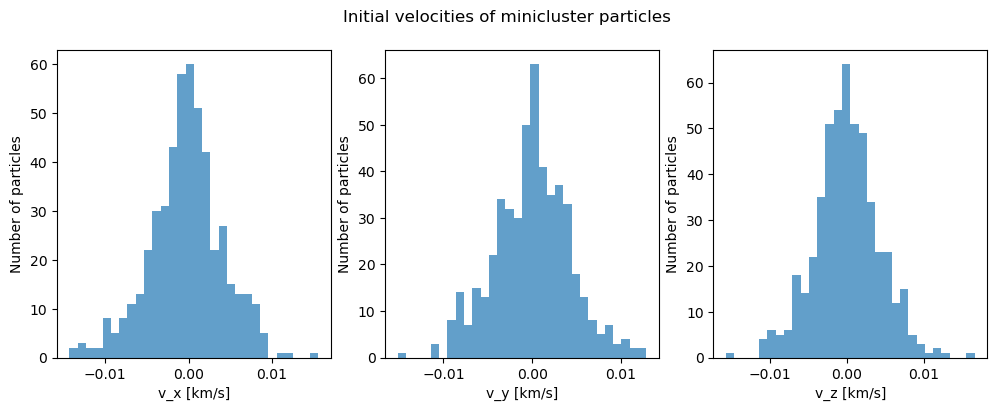

In [12]:
fig,ax=plt.subplots(1,3, figsize=(12,4))
fig.suptitle('Initial velocities of minicluster particles')

ax[0].hist(mcp_xv[:,3], bins=30, alpha=0.7, label='v_x')
ax[0].set_xlabel('v_x [km/s]')
ax[0].set_ylabel('Number of particles')
ax[1].hist(mcp_xv[:,4], bins=30, alpha=0.7, label='v_y')
ax[1].set_xlabel('v_y [km/s]')
ax[1].set_ylabel('Number of particles')
ax[2].hist(mcp_xv[:,5], bins=30, alpha=0.7, label='v_z')
ax[2].set_xlabel('v_z [km/s]')
ax[2].set_ylabel('Number of particles')


In [13]:
solar_pos = np.array([8.0, 0.0, 0.0, 0.0, 0.0, 220.0]) 


In [14]:
N_orbits=0.5
orbit_time = N_orbits *    pot_mw.Tcirc(solar_pos)


In [15]:
mc_center=reverse_orbit(solar_pos, pot_mw,N_orbits*pot_mw.Tcirc(solar_pos),4, 10)

Starting position: [  -6.492611     0.           1.6569884   21.354347     0.
 -263.123    ]


In [16]:
mc_center=np.array([8,0,0,0,0,220])

In [17]:
mcp_xv += mc_center

In [18]:
def N_encounter_new(t,xv, b_max=1e-4):
    return np.trapezoid(stellar_rho_total(xv[:,0], xv[:,1], xv[:,2]) * np.linalg.norm(xv[:, 3:],axis=1) * np.full_like(t,np.pi)  * np.full_like(t,b_max**2),t)

In [19]:
def dynamical_time(mc_mass,mc_rvir,density=None):
    rho= ((3*mc_mass)/(4*np.pi*mc_rvir**3)) # mean density of the minicluster
    if density is not None:
        print('Density of the bound object is:', rho)
    return np.sqrt((3*np.pi)/(16*agama.G*rho))

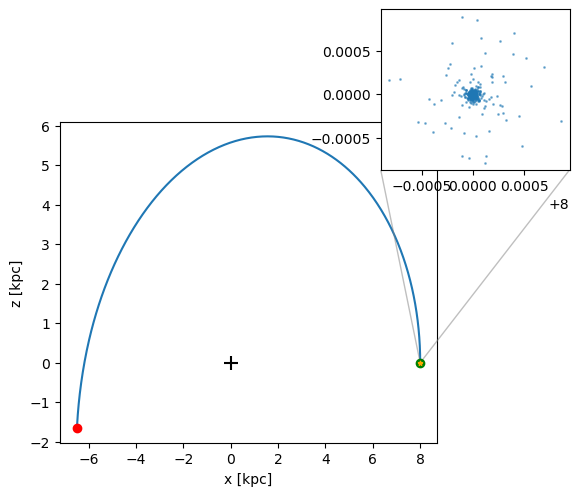

In [20]:
time_test, traj = agama.orbit(ic=mc_center, potential=pot_mw, time=N_orbits*pot_mw.Tcirc(mc_center), trajsize=500)
fig,ax=plt.subplots()
ax.plot(traj[:, 0], traj[:, 2])
ax.scatter(traj[0, 0],  traj[0, 2],  color='g', zorder=5, label='Start')
ax.scatter(traj[-1, 0], traj[-1, 2], color='r', zorder=5, label='End')
ax.scatter(8.0, 0.0, marker='*', s=10, color='yellow', edgecolors='orange', zorder=5, label='Sun')
ax.scatter(0.0, 0.0, marker='+', s=100, color='black', zorder=5, label='Galactic center')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')


ax.scatter(mcp_xv[:,0], mcp_xv[:,2], s=1, alpha=0.5, label='Minicluster particles')

axz=ax.inset_axes([0.85, 0.85, 0.5, 0.5])
axz.scatter(mcp_xv[:,0], mcp_xv[:,2], s=1, alpha=0.5)
ax.indicate_inset_zoom(axz)
ax.set_box_aspect(0.85)
fig.subplots_adjust(left=0.11, right=0.7)


In [21]:
def stellar_energy(N,M,R,v,its_sum):
    b=np.random.uniform(1e-5, 1e-4,N)

    E=((4*agama.G*agama.G*M*0.27*R*R)/((b**4)*v**2)*3)
    E_sum=np.sum(E)
    E_rms_sum=np.sum(np.sqrt(E))**2
    if its_sum:
        print(E_sum,N,'sum')
        return E_sum
    else:
        print(E_rms_sum,N,'rms')
        return E_rms_sum

In [22]:
mcp_xv 

array([[ 8.00000778e+00,  5.29524953e-05, -1.00927789e-05,
        -6.11882791e-04,  4.22427480e-03,  2.20003572e+02],
       [ 7.99999870e+00, -3.21867233e-06, -6.07355687e-06,
         1.13948174e-02,  5.58288024e-03,  2.19997540e+02],
       [ 8.00012242e+00, -5.59562294e-04, -7.86041224e-04,
        -2.72864440e-04,  1.77540898e-04,  2.20000878e+02],
       ...,
       [ 7.99999403e+00,  1.11438413e-05, -4.96616298e-08,
        -1.23581492e-03, -8.19526235e-03,  2.20006186e+02],
       [ 8.00000522e+00,  3.53927036e-05, -6.71999671e-05,
        -3.02837346e-03,  3.49375029e-04,  2.19997606e+02],
       [ 7.99999805e+00,  4.33564491e-06, -8.89129020e-06,
         1.16356787e-03,  6.92919173e-03,  2.20007982e+02]],
      shape=(500, 6))

In [30]:
def stellar_kick(E,xv):
    print('old velocities', xv[:, 3:])
    v_kick=np.sqrt(2*E)/Nbody
    print('v_kick',v_kick)
    v_kick=v_kick*uniform_direction.rvs(3)
    print('v_kick direction',v_kick)
    xv[:, 3:] += v_kick
    print('new velocities', xv[:, 3:])
    return xv

    

    

In [31]:
gg=stellar_kick(10000,mcp_xv)


old velocities [[-1.16847535e-02  4.46461469e-01  2.19911448e+02]
 [ 3.21946670e-04  4.47820074e-01  2.19905416e+02]
 [-1.71841604e-01  2.09760955e-01  2.19919398e+02]
 ...
 [-1.72804554e-01  2.01388152e-01  2.19924706e+02]
 [-1.74597113e-01  2.09932789e-01  2.19916126e+02]
 [-1.70405171e-01  2.16512606e-01  2.19926502e+02]]
v_kick 0.282842712474619
v_kick direction [ 0.26383029 -0.07475067 -0.06932472]
new velocities [[2.52145533e-01 3.71710797e-01 2.19842123e+02]
 [2.64152233e-01 3.73069403e-01 2.19836091e+02]
 [9.19886825e-02 1.35010284e-01 2.19850074e+02]
 ...
 [9.10257321e-02 1.26637481e-01 2.19855382e+02]
 [8.92331735e-02 1.35182118e-01 2.19846802e+02]
 [9.34251148e-02 1.41761935e-01 2.19857178e+02]]


In [33]:
mcp_xv-gg

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]], shape=(500, 6))

In [123]:
mcp_xv[:2]

array([[-6.5005560e+00,  4.0638483e-06, -1.7642384e+00, -1.7500721e+01,
         2.5609618e-01, -2.6145621e+02],
       [-6.5005507e+00,  1.6923044e-06, -1.7642347e+00, -1.7491037e+01,
         2.2960559e-01, -2.6147656e+02]], dtype=float32)

In [55]:
simulation_time = orbit_time
tupd            = 1e-3 # update interval [Gyr]: CoM step + N-body step

mcp_xv_init    = mcp_xv.copy()
mc_center_init = mc_center.copy()

times_u = [0.0]
mc_mass = [mc_mass0]
mc_traj = [mc_center.copy()]
bound   = np.ones(len(mcp_xv), dtype=bool)  # all particles start bound
time_i  = 0.0
N_enc=[]
T_dyn=[dynamical_time(mc_mass0, mc_rvir)]
star_N=[]
E_stellar_array=[]
KE_array=[]
PE_array=[]


In [56]:
dynamical_time(mc_mass0, mc_rvir,density=True)

Density of the bound object is: 238732414.63784283


np.float64(0.02395186485713765)

In [57]:

n_steps = round(simulation_time / tupd)

with tqdm(total=n_steps) as pbar:
    while time_i < simulation_time:

        mc_time_center, mc_orbit_center = agama.orbit(ic=mc_center, potential=pot_mw, time=tupd,timestart=time_i, trajsize=100, accuracy=1e-10)
        times_u.append(mc_time_center[-1])
        mc_traj.extend(mc_orbit_center[1:])
        mc_center = mc_orbit_center[-1]

        

        N_encounter_with_star=N_encounter_new(mc_time_center, mc_orbit_center,b_max=0.0001)
        N_enc.append(N_encounter_with_star)
        T_dyn.append(tupd/N_encounter_with_star)
        #print('timescales',tupd/N_encounter_with_star,dynamical_time(mc_mass0, mc_rvir))
        
        its_sum=tupd/N_encounter_with_star/dynamical_time(mc_mass0, mc_rvir)*100>1


        E_stellar=stellar_energy(int(N_encounter_with_star), mc_mass0, mc_rvir, np.mean(np.linalg.norm(mc_orbit_center[:, 3:],axis=1)),its_sum)
        E_stellar_array.append(E_stellar)

        #  Advance N-body particles in combined MW + moving cluster potential 
        pot_total = agama.Potential(
            pot_mw,
            agama.Potential(potential=pot_mc,
                            center=np.column_stack((mc_time_center, mc_orbit_center))))
        mcp_xv = np.vstack(
            agama.orbit(ic=mcp_xv, potential=pot_total,
                        time=tupd, timestart=time_i, trajsize=1, accuracy=1e-10)[:, 1])

        #  Relative coordinates in cluster rest frame 
        rel_pos = mcp_xv[:, :3] - mc_center[:3]
        rel_vel = mcp_xv[:, 3:6] - mc_center[3:6]
        pos_f=mcp_xv[:, :3]
        vel_f=mcp_xv[:, 3:6]

        n_bound = np.sum(bound)

        pot_mc = agama.Potential(
                type='multipole',
                particles=(rel_pos, mcp_mass),
                symmetry='n', lmax=4)  

        bound_energy = pot_mc.potential(rel_pos) + 0.5 * np.sum(rel_vel**2, axis=1) < 0
        bound        = bound_energy

        PE_array.append(np.sum(pot_mc.potential(rel_pos)))
        KE_array.append(np.sum(0.5 * np.sum(rel_vel**2, axis=1)))

        mc_mass.append(np.sum(mcp_mass[bound]))
        time_i += tupd

        pbar.update(1)
mc_traj=np.array(mc_traj)

  0%|          | 0/82 [00:00<?, ?it/s]

0.002853817863972858 486 rms
0.0007183715027596598 253 rms
0.00028515785316783946 137 rms


500 orbits complete (20833 orbits/s)
500 orbits complete (6667 orbits/s)
500 orbits complete (6494 orbits/s)


8.190570705107449e-05 79 rms
2.6526603420335424e-05 48 rms
7.93633741165564e-06 31 rms


500 orbits complete (6494 orbits/s)
500 orbits complete (6410 orbits/s)
500 orbits complete (6250 orbits/s)


...

500 orbits complete (2591 orbits/s)
500 orbits complete (3521 orbits/s)


0.00010440788917026895 145 rms
4.918735801306551e-05 76 rms


500 orbits complete (3676 orbits/s)
500 orbits complete (3650 orbits/s)


1.8638171735894237e-05 44 rms
1.2144175354469724e-05 27 rms


500 orbits complete (1859 orbits/s)


In [59]:
#making all into np
times_u=np.array(times_u)
mc_mass=np.array(mc_mass)
mc_traj=np.array(mc_traj)
N_enc=np.array(N_enc)
T_dyn=np.array(T_dyn)
KE_array=np.array(KE_array)
PE_array=np.array(PE_array)
E_stellar_array=np.array(E_stellar_array)

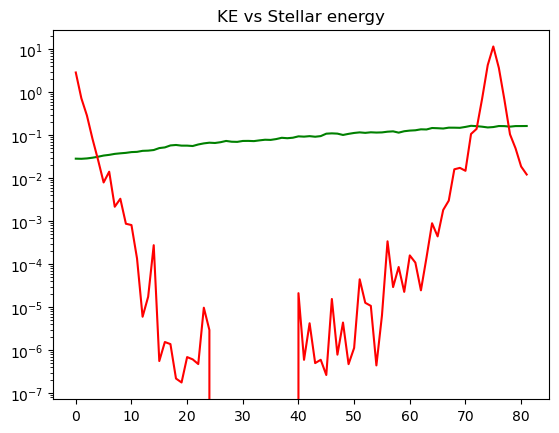

In [83]:
plt.title('KE vs Stellar energy')
plt.plot(2*KE_array,'g')
plt.plot(E_stellar_array/mc_mass0,'r')
plt.yscale('log')


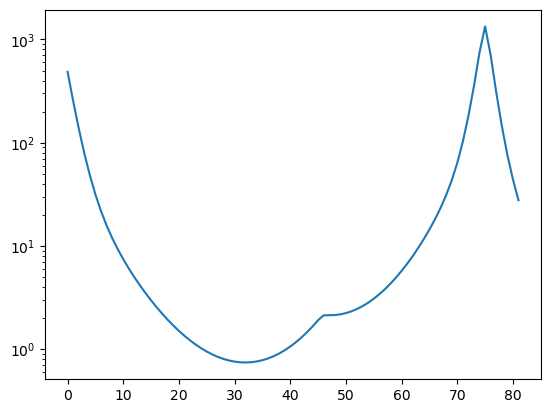

In [84]:

plt.plot(np.array(N_enc))

plt.yscale('log')

In [88]:
E_stellar_array

[0,
 np.float64(0.0031114626192852647),
 np.float64(0.0006887702885742006),
 np.float64(0.0005176795594747753),
 np.float64(8.637373257019176e-05),
 np.float64(4.3018964590757265e-05),
 np.float64(2.2358157970980215e-05),
 np.float64(3.0522000552162743e-06),
 np.float64(5.001934999409336e-06),
 np.float64(7.409566182922641e-07),
 np.float64(1.0719715764998239e-06),
 np.float64(3.6841326997819956e-08),
 np.float64(6.405201136299656e-08),
 np.float64(1.5384160445965228e-07),
 np.float64(3.280886696667092e-07),
 np.float64(5.635927797306452e-07),
 np.float64(2.757426820047702e-09),
 np.float64(1.2078472354396936e-08),
 np.float64(2.7654748833759265e-09),
 np.float64(1.2139633665208756e-10),
 np.float64(3.3354280583279397e-10),
 np.float64(1.815690049772033e-10),
 np.float64(1.8602207670923673e-08),
 np.float64(3.0260425745086037e-10),
 np.float64(4.350539209394967e-09),
 np.float64(3.2710946175720484e-10),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64

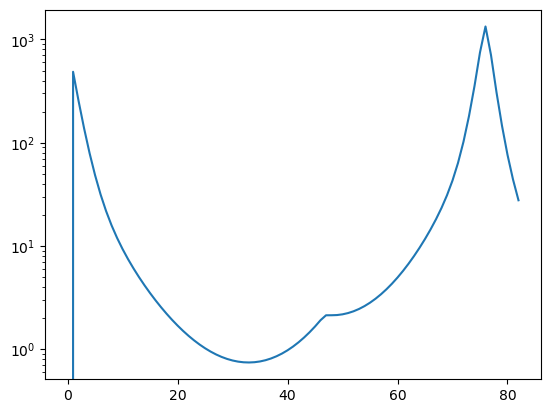

In [89]:
plt.plot(N_enc)
plt.yscale('log')

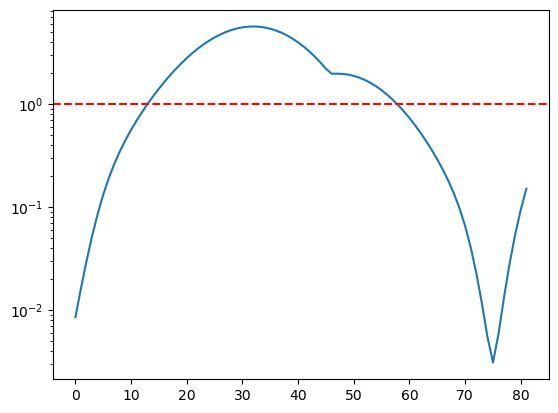

In [90]:
T_dyn=np.array(T_dyn)
plt.plot(T_dyn[1:]/T_dyn[0]*100)
plt.yscale('log')
plt.axhline(1, color='r', linestyle='--')

In [91]:
T_dyn[1:]*100

array([2.05661759e-04, 3.94627307e-04, 7.25460283e-04, 1.26305629e-03,
       2.06701716e-03, 3.17434515e-03, 4.59535198e-03, 6.32662882e-03,
       8.36883816e-03, 1.07366291e-02, 1.34587754e-02, 1.65731813e-02,
       2.01209384e-02, 2.41411182e-02, 2.86665113e-02, 3.37199436e-02,
       3.93109889e-02, 4.54328359e-02, 5.20595404e-02, 5.91436280e-02,
       6.66142953e-02, 7.43765753e-02, 8.23114362e-02, 9.02772838e-02,
       9.81128943e-02, 1.05641554e-01, 1.12676999e-01, 1.19030354e-01,
       1.24518048e-01, 1.28970255e-01, 1.32239583e-01, 1.34208745e-01,
       1.34797719e-01, 1.33968858e-01, 1.31729996e-01, 1.28135106e-01,
       1.23282382e-01, 1.17309854e-01, 1.10388724e-01, 1.02714842e-01,
       9.44991640e-02, 8.59575294e-02, 7.73008349e-02, 6.87258851e-02,
       6.04078599e-02, 5.24946289e-02, 4.70364282e-02, 4.69992110e-02,
       4.67913898e-02, 4.60434650e-02, 4.47750299e-02, 4.30249114e-02,
       4.08491563e-02, 3.83177900e-02, 3.55108182e-02, 3.25135982e-02,
      

In [92]:
T_dyn[1:]

array([2.05661759e-06, 3.94627307e-06, 7.25460283e-06, 1.26305629e-05,
       2.06701716e-05, 3.17434515e-05, 4.59535198e-05, 6.32662882e-05,
       8.36883816e-05, 1.07366291e-04, 1.34587754e-04, 1.65731813e-04,
       2.01209384e-04, 2.41411182e-04, 2.86665113e-04, 3.37199436e-04,
       3.93109889e-04, 4.54328359e-04, 5.20595404e-04, 5.91436280e-04,
       6.66142953e-04, 7.43765753e-04, 8.23114362e-04, 9.02772838e-04,
       9.81128943e-04, 1.05641554e-03, 1.12676999e-03, 1.19030354e-03,
       1.24518048e-03, 1.28970255e-03, 1.32239583e-03, 1.34208745e-03,
       1.34797719e-03, 1.33968858e-03, 1.31729996e-03, 1.28135106e-03,
       1.23282382e-03, 1.17309854e-03, 1.10388724e-03, 1.02714842e-03,
       9.44991640e-04, 8.59575294e-04, 7.73008349e-04, 6.87258851e-04,
       6.04078599e-04, 5.24946289e-04, 4.70364282e-04, 4.69992110e-04,
       4.67913898e-04, 4.60434650e-04, 4.47750299e-04, 4.30249114e-04,
       4.08491563e-04, 3.83177900e-04, 3.55108182e-04, 3.25135982e-04,
      

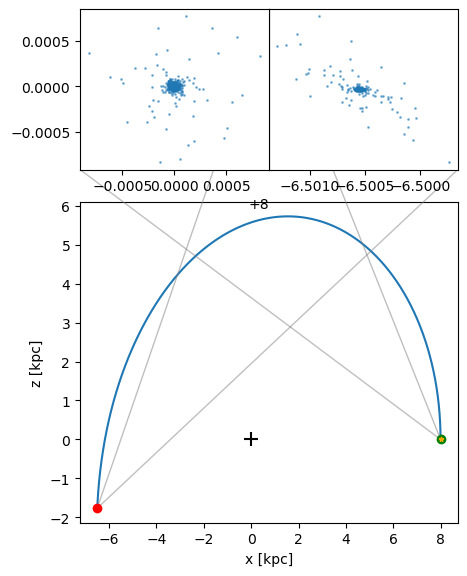

In [93]:
fig,ax=plt.subplots()
ax.plot(mc_traj[:, 0], mc_traj[:, 2])
ax.scatter(mc_traj[0, 0],  mc_traj[0, 2],  color='g', zorder=5, label='Start')
ax.scatter(mc_traj[-1, 0], mc_traj[-1, 2], color='r', zorder=5, label='End')
ax.scatter(8.0, 0.0, marker='*', s=10, color='yellow', edgecolors='orange', zorder=5, label='Sun')
ax.scatter(0.0, 0.0, marker='+', s=100, color='black', zorder=5, label='Galactic center')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')

ax.scatter(pos_f[:,0], pos_f[:,2], s=1, alpha=0.5, label='Minicluster particles')

axz=ax.inset_axes([0.5, 1.1, 0.5, 0.5])
axz.scatter(pos_f[:,0], pos_f[:,2], s=1, alpha=0.5)
ax.indicate_inset_zoom(axz)
ax.set_box_aspect(0.85)
fig.subplots_adjust(left=0.11, right=0.7)

ax.scatter(mcp_xv[:,0], mcp_xv[:,2], s=1, alpha=0.5, label='Minicluster particles')

axz2=ax.inset_axes([0, 1.1, 0.5, 0.5])
axz2.scatter(mcp_xv_init[:,0], mcp_xv_init[:,2], s=1, alpha=0.5)
ax.indicate_inset_zoom(axz2)
ax.set_box_aspect(0.85)
fig.subplots_adjust(left=0.11, right=0.7)

In [94]:
import plotly.graph_objects as go

fig = go.Figure(data=[
    go.Scatter3d(
        x=pos_f[bound, 0],  y=pos_f[bound, 1],  z=pos_f[bound, 2],
        mode='markers', marker=dict(size=1, color='limegreen', opacity=0.5),
        name=f'Bound ({bound.sum()})'
    ),
    go.Scatter3d(
        x=pos_f[~bound, 0], y=pos_f[~bound, 1], z=pos_f[~bound, 2],
        mode='markers', marker=dict(size=1, color='crimson', opacity=0.3),
        name=f'Unbound ({(~bound).sum()})'
    ),
    go.Scatter3d(
        x=[solar_pos[0]], y=[solar_pos[1]], z=[solar_pos[2]],
        mode='markers', marker=dict(size=6, color='yellow', symbol='diamond'),
        name='Sun'
    )
])

fig.update_layout(
    scene=dict(xaxis_title='x [kpc]', yaxis_title='y [kpc]', zaxis_title='z [kpc]'),
    title='Final particle positions'
)
fig.show()


Text(0, 0.5, 'z [kpc]')

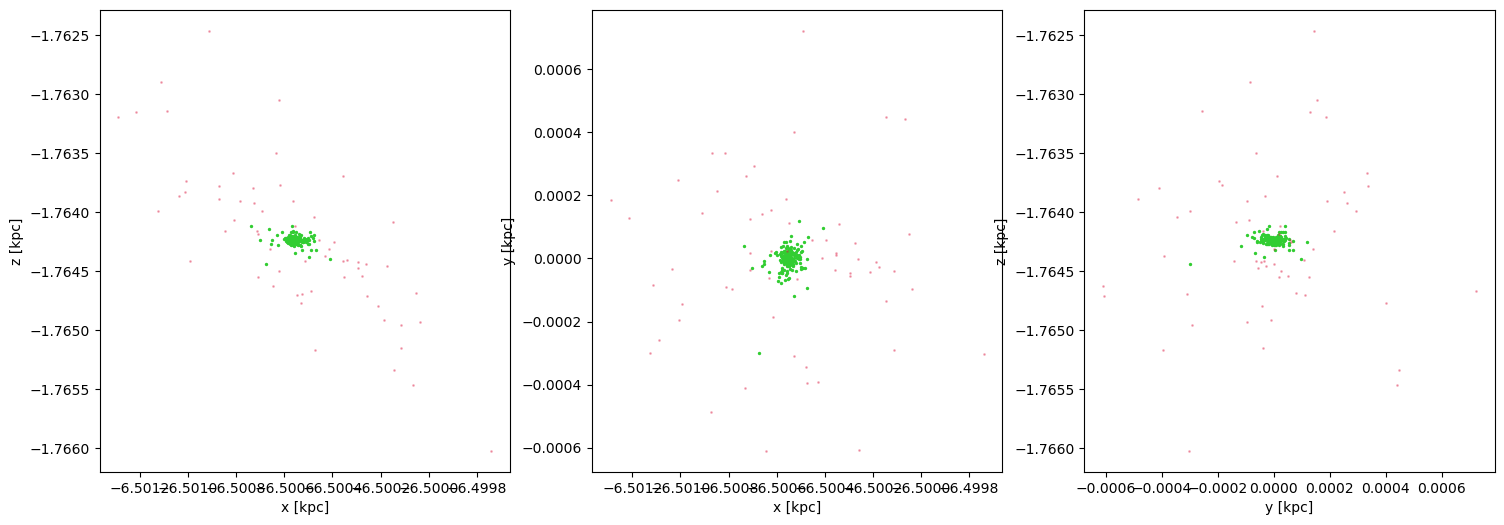

In [95]:


fig, axes = plt.subplots(1,3, figsize=(18, 6))


ax = axes[0]
ax.scatter(pos_f[bound,  0], pos_f[bound,  2], s=2,   color='limegreen',label=f'Bound ({bound.sum()})')
ax.scatter(pos_f[~bound, 0], pos_f[~bound, 2], s=1, color='crimson', alpha=0.3,label=f'Unbound ({(~bound).sum()})')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')
#ax.set_xlim(7.995,8.005)
#ax.set_ylim(0.08,0.095)
#plt.scatter(solar_pos[0], solar_pos[2], marker='*', s=100, color='yellow', edgecolors='orange', zorder=5, label='Sun')
ax=axes[1]
ax.scatter(pos_f[bound,  0], pos_f[bound,  1], s=2,   color='limegreen',label=f'Bound ({bound.sum()})')
ax.scatter(pos_f[~bound, 0], pos_f[~bound, 1], s=1, color='crimson', alpha=0.3,label=f'Unbound ({(~bound).sum()})')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
#ax.set_xlim(7.995,8.005)
ax=axes[2]
ax.scatter(pos_f[bound,  1], pos_f[bound,  2], s=2,   color='limegreen',label=f'Bound ({bound.sum()})')
ax.scatter(pos_f[~bound, 1], pos_f[~bound, 2], s=1, color='crimson', alpha=0.3,label=f'Unbound ({(~bound).sum()})')
ax.set_xlabel('y [kpc]')
ax.set_ylabel('z [kpc]')


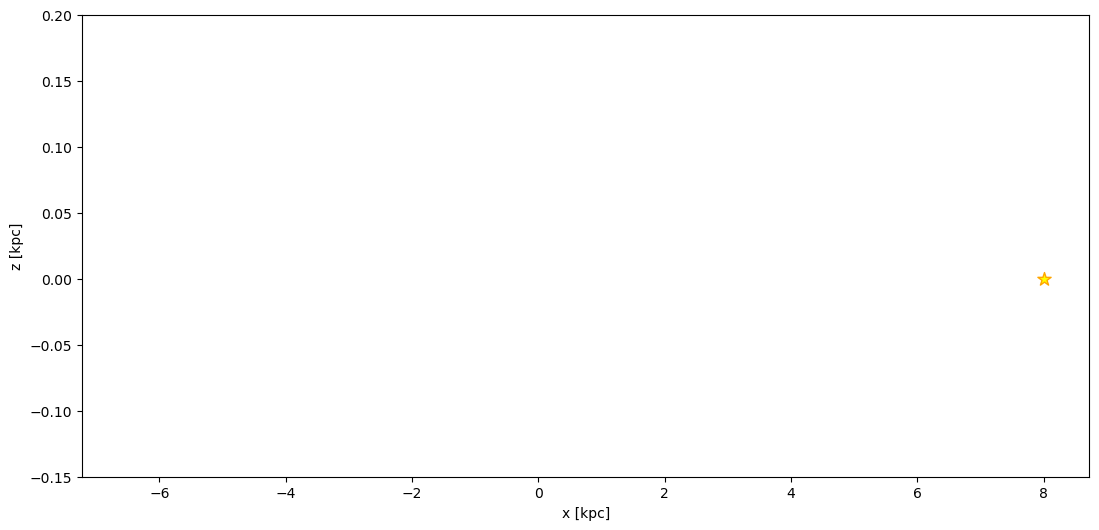

In [96]:


fig, axes = plt.subplots(figsize=(13, 6))


ax = axes
ax.scatter(pos_f[bound,  0], pos_f[bound,  2], s=2,   color='limegreen',label=f'Bound ({bound.sum()})')
ax.scatter(pos_f[~bound, 0], pos_f[~bound, 2], s=1, color='crimson', alpha=0.3,label=f'Unbound ({(~bound).sum()})')
ax.set_xlabel('x [kpc]')
ax.set_ylabel('z [kpc]')
#ax.set_xlim(7.97,8.02)
ax.set_ylim(-0.15,0.2)
plt.scatter(solar_pos[0], solar_pos[2], marker='*', s=100, color='yellow', edgecolors='orange', zorder=5, label='Sun')

Text(0.5, 1.0, 'Number of encounters over time')

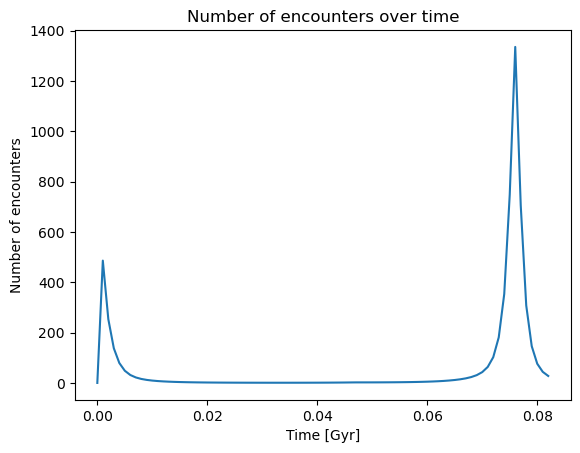

In [97]:
plt.plot(times_u,N_enc)
plt.xlabel('Time [Gyr]')
plt.ylabel('Number of encounters')
plt.title('Number of encounters over time')
#plt.yscale('log')

In [98]:
np.sum(bound)

np.int64(439)

In [99]:
np.sum(~bound)

np.int64(61)

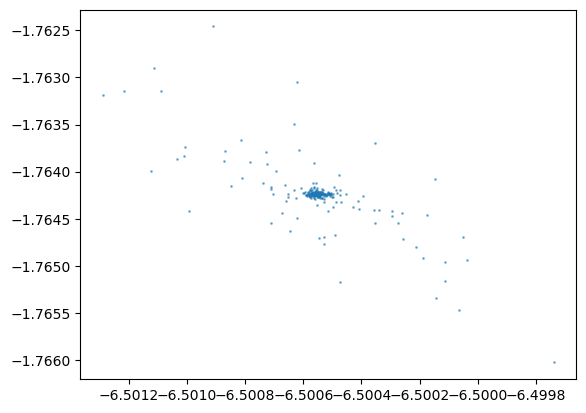

In [100]:
plt.scatter(mcp_xv[:,0], mcp_xv[:,2], s=1, alpha=0.5, label='Minicluster particles')